In [2]:
# ============================================================
# step 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Data splitting and validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    learning_curve
)

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Display settings
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ============================================================
# Step 2: LOAD DATASET
# ============================================================

# Load the Breast Cancer dataset
data = load_breast_cancer()

# Create feature DataFrame
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Target variable
y = pd.Series(
    data.target,
    name="Target"
)

# Target classes:
# 0 = Malignant
# 1 = Benign

print("=" * 60)
print("BREAST CANCER DATASET")
print("=" * 60)

print(f"Dataset Shape: {X.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"Number of Samples: {X.shape[0]}")

BREAST CANCER DATASET
Dataset Shape: (569, 30)
Number of Features: 30
Number of Samples: 569


In [4]:
# ============================================================
# Step 3: DATASET EXPLORATION
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nFirst 5 Rows:")
display(X.head())

print("\nFeature Information:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nClass Distribution:")
print(y.value_counts())

print("\nClass Distribution (%):")
class_distribution = (
    y.value_counts(normalize=True)
     .mul(100)
     .round(2)
)

print(class_distribution)

DATASET INFORMATION

First 5 Rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Feature Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

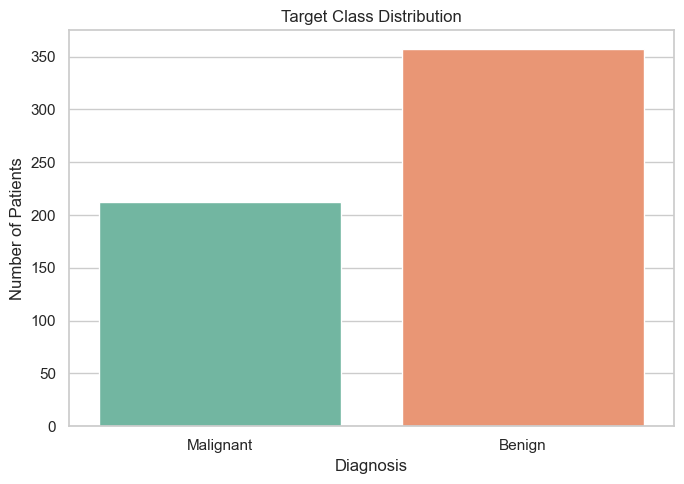

In [5]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y,
    hue=y,
    palette="Set2",
    legend=False
)

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.title("Target Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Step 4: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Target   : {y_train.shape}")
print(f"Testing Target    : {y_test.shape}")

TRAIN-TEST SPLIT
Training Features : (455, 30)
Testing Features  : (114, 30)
Training Target   : (455,)
Testing Target    : (114,)


In [8]:
# ============================================================
# Step 5: FEATURE SCALING
# ============================================================

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [9]:
# ============================================================
# CELL 6: DEFINE CLASSIFICATION MODELS
# ============================================================

# Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Gradient Boosting
gb = GradientBoostingClassifier(
    random_state=42
)

print("Models created successfully.")

Models created successfully.


In [10]:
# ============================================================
# Step 7: TRAIN MODELS
# ============================================================

# Logistic Regression
lr.fit(
    X_train_scaled,
    y_train
)

# Random Forest
rf.fit(
    X_train,
    y_train
)

# Gradient Boosting
gb.fit(
    X_train,
    y_train
)

print("=" * 60)
print("MODEL TRAINING COMPLETED")
print("=" * 60)

print("✓ Logistic Regression trained")
print("✓ Random Forest trained")
print("✓ Gradient Boosting trained")

MODEL TRAINING COMPLETED
✓ Logistic Regression trained
✓ Random Forest trained
✓ Gradient Boosting trained


In [11]:
# ============================================================
# CELL 8: MAKE PREDICTIONS
# ============================================================

# Class predictions
lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

# Probability predictions
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]
gb_proba = gb.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [12]:
# ============================================================
# Step 9: MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_proba
):
    """
    Calculate and return classification evaluation metrics.
    """

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

In [13]:
# ============================================================
# Step 10: MODEL EVALUATION
# ============================================================

results = []

# Logistic Regression
results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred,
        lr_proba
    )
)

# Random Forest
results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_proba
    )
)

# Gradient Boosting
results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred,
        gb_proba
    )
)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Round values
results_df = results_df.round(4)

print("=" * 70)
print("MODEL EVALUATION RESULTS")
print("=" * 70)

display(results_df)

MODEL EVALUATION RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
1,Random Forest,0.9561,0.9589,0.9722,0.9655,0.9931
2,Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9907


In [14]:
# ============================================================
# Step 11: CLASSIFICATION REPORTS
# ============================================================

models_predictions = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

for model_name, predictions in models_predictions.items():

    print("\n" + "=" * 70)
    print(model_name.upper())
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Malignant",
                "Benign"
            ]
        )
    )


LOGISTIC REGRESSION
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


RANDOM FOREST
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


GRADIENT BOOSTING
              precision    recall  f1-score   support

   Malignant       0.97      0.90      0.94        42
      Benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       

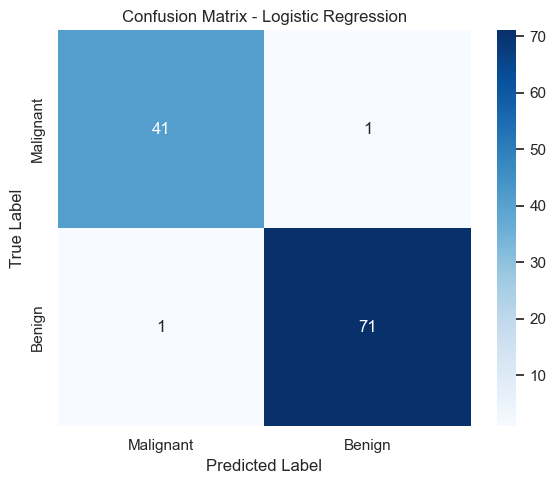

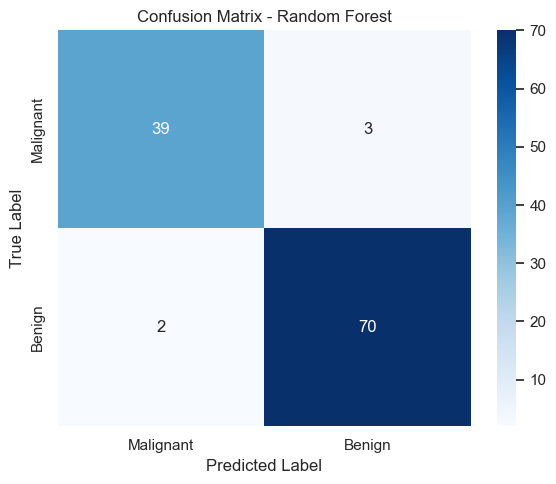

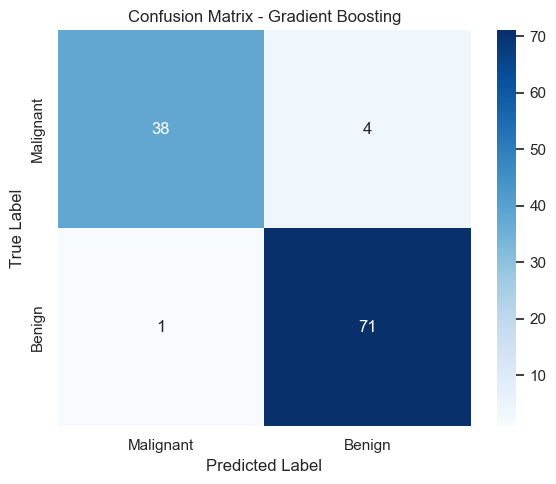

In [15]:
# ============================================================
# Step 12: CONFUSION MATRICES
# ============================================================

confusion_matrices = {
    "Logistic Regression": confusion_matrix(
        y_test,
        lr_pred
    ),

    "Random Forest": confusion_matrix(
        y_test,
        rf_pred
    ),

    "Gradient Boosting": confusion_matrix(
        y_test,
        gb_pred
    )
}

for model_name, cm in confusion_matrices.items():

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Malignant",
            "Benign"
        ],
        yticklabels=[
            "Malignant",
            "Benign"
        ]
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

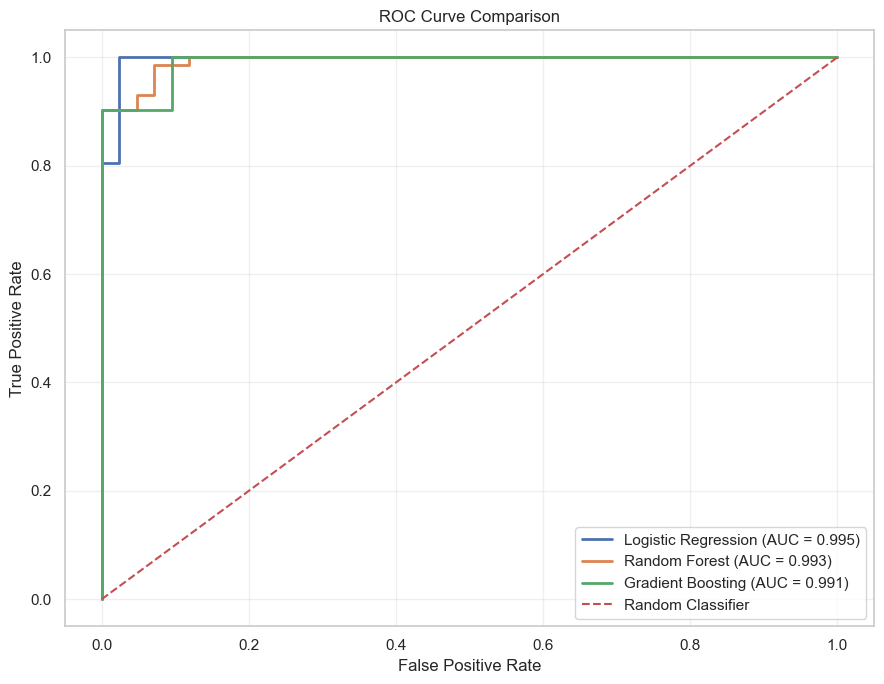

In [16]:
# ============================================================
# Step 13: ROC CURVE COMPARISON
# ============================================================

# Calculate ROC curves

lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_proba
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_proba
)

gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_proba
)

# Calculate AUC

lr_auc = roc_auc_score(
    y_test,
    lr_proba
)

rf_auc = roc_auc_score(
    y_test,
    rf_proba
)

gb_auc = roc_auc_score(
    y_test,
    gb_proba
)


# Plot
plt.figure(figsize=(9, 7))

plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    linewidth=2,
    label=f"Gradient Boosting (AUC = {gb_auc:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Step 14: STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

lr_cv = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="f1"
)

cv_results.append({
    "Model": "Logistic Regression",
    "Mean F1": lr_cv.mean(),
    "Std F1": lr_cv.std()
})


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

cv_results.append({
    "Model": "Random Forest",
    "Mean F1": rf_cv.mean(),
    "Std F1": rf_cv.std()
})


# ------------------------------------------------------------
# Gradient Boosting
# ------------------------------------------------------------

gb_cv = cross_val_score(
    gb,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

cv_results.append({
    "Model": "Gradient Boosting",
    "Mean F1": gb_cv.mean(),
    "Std F1": gb_cv.std()
})


# Results
cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.round(4)

print("=" * 70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

display(cv_df)

5-FOLD CROSS-VALIDATION RESULTS


,Model,Mean F1,Std F1
0,Logistic Regression,0.9825,0.0078
1,Random Forest,0.9700,0.0146
2,Gradient Boosting,0.9614,0.0121


In [19]:
# ============================================================
# Step 15: LEARNING CURVE FUNCTION
# ============================================================

def plot_learning_curve(
    model,
    X_data,
    y_data,
    model_name
):
    """
    Plot training and validation F1 scores.
    """

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring="f1",
        train_sizes=np.linspace(
            0.1,
            1.0,
            10
        ),
        n_jobs=-1
    )

    train_mean = np.mean(
        train_scores,
        axis=1
    )

    val_mean = np.mean(
        val_scores,
        axis=1
    )

    plt.figure(figsize=(8, 6))

    plt.plot(
        train_sizes,
        train_mean,
        marker="o",
        label="Training F1"
    )

    plt.plot(
        train_sizes,
        val_mean,
        marker="s",
        linestyle="--",
        label="Validation F1"
    )

    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")

    plt.title(
        f"Learning Curve - {model_name}"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

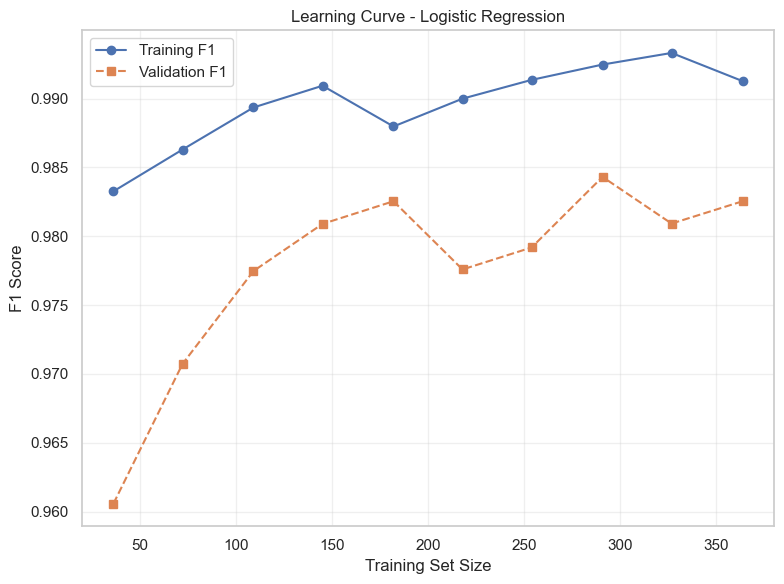

In [20]:
# ============================================================
# Step 16: LOGISTIC REGRESSION LEARNING CURVE
# ============================================================

plot_learning_curve(
    lr,
    X_train_scaled,
    y_train,
    "Logistic Regression"
)

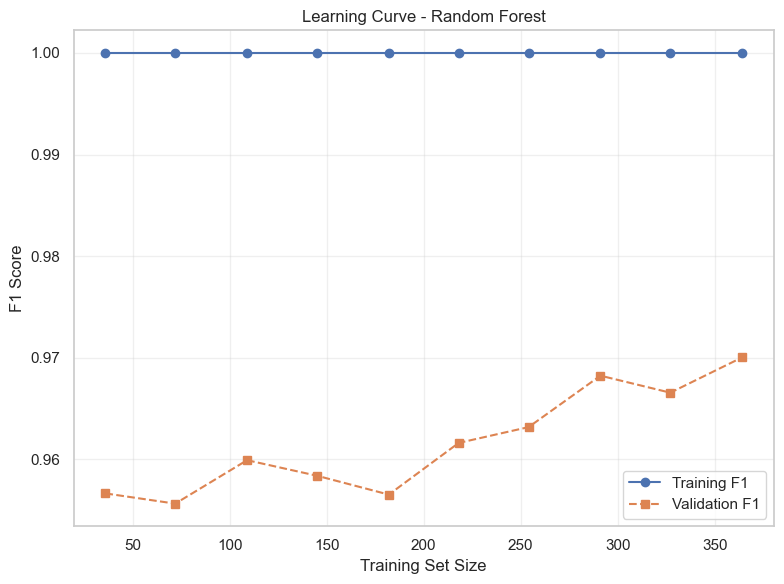

In [21]:
# ============================================================
# Step 17: RANDOM FOREST LEARNING CURVE
# ============================================================

plot_learning_curve(
    rf,
    X_train,
    y_train,
    "Random Forest"
)

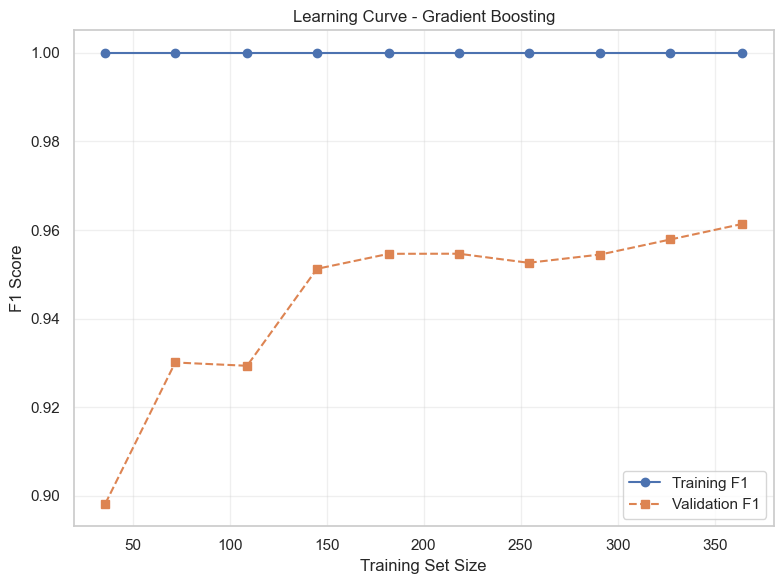

In [22]:
# ============================================================
# Step 18: GRADIENT BOOSTING LEARNING CURVE
# ============================================================

plot_learning_curve(
    gb,
    X_train,
    y_train,
    "Gradient Boosting"
)

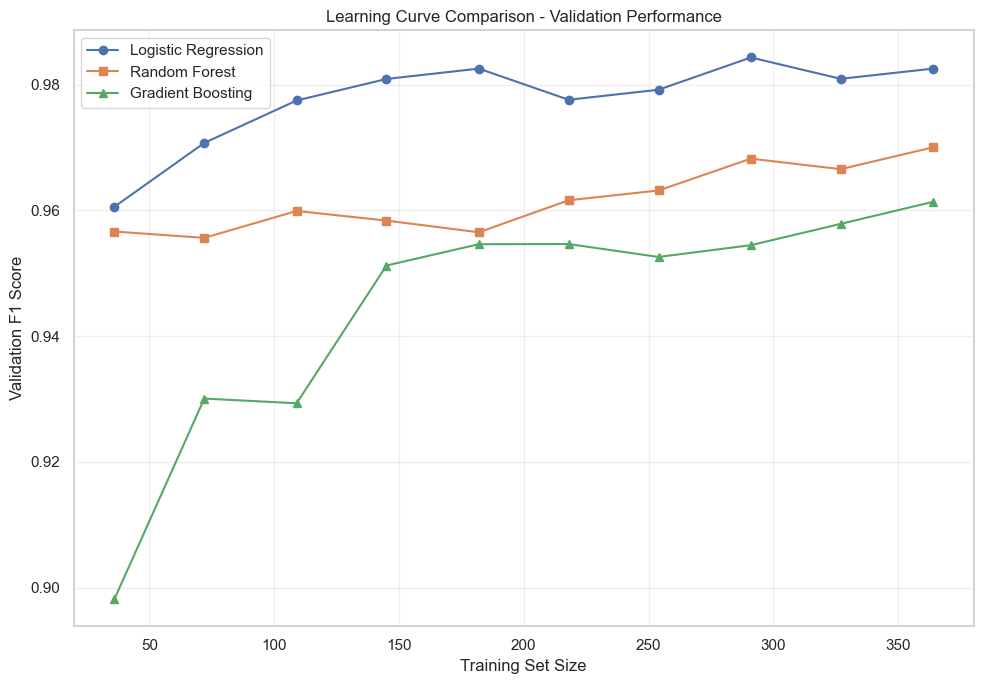

In [23]:
# ============================================================
# Step 19: LEARNING CURVE COMPARISON
# ============================================================

def get_learning_curve_data(
    model,
    X_data,
    y_data
):

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring="f1",
        train_sizes=np.linspace(
            0.1,
            1.0,
            10
        ),
        n_jobs=-1
    )

    return (
        train_sizes,
        train_scores.mean(axis=1),
        val_scores.mean(axis=1)
    )


# Get learning curve data

lr_sizes, lr_train, lr_val = get_learning_curve_data(
    lr,
    X_train_scaled,
    y_train
)

rf_sizes, rf_train, rf_val = get_learning_curve_data(
    rf,
    X_train,
    y_train
)

gb_sizes, gb_train, gb_val = get_learning_curve_data(
    gb,
    X_train,
    y_train
)


# Plot

plt.figure(figsize=(10, 7))

plt.plot(
    lr_sizes,
    lr_val,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    rf_sizes,
    rf_val,
    marker="s",
    label="Random Forest"
)

plt.plot(
    gb_sizes,
    gb_val,
    marker="^",
    label="Gradient Boosting"
)

plt.xlabel("Training Set Size")
plt.ylabel("Validation F1 Score")

plt.title(
    "Learning Curve Comparison - Validation Performance"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

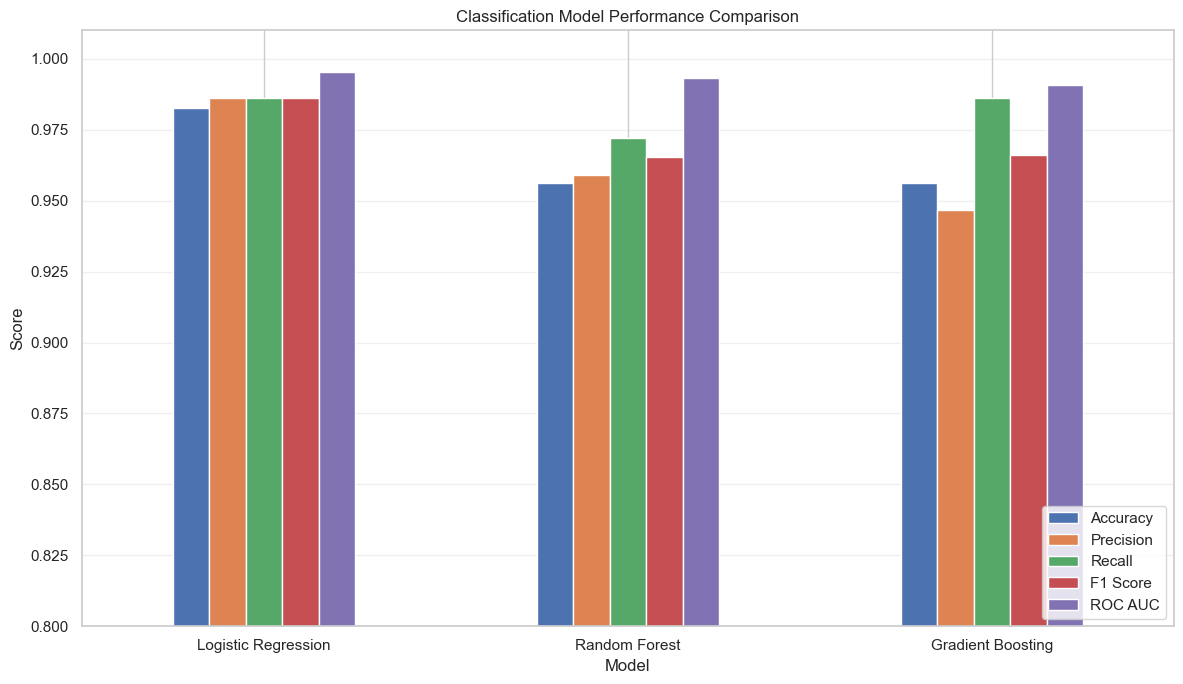

In [24]:
# ============================================================
# Step 20: MODEL PERFORMANCE COMPARISON
# ============================================================

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

comparison_df = results_df.set_index(
    "Model"
)[metrics_to_plot]

plt.figure(figsize=(12, 7))

comparison_df.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Classification Model Performance Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0.80, 1.01)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# Step 21: IDENTIFY BEST MODEL
# ============================================================

best_model_row = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    f"Best Model: {best_model_row['Model']}"
)

print(
    f"Accuracy  : {best_model_row['Accuracy']:.4f}"
)

print(
    f"Precision : {best_model_row['Precision']:.4f}"
)

print(
    f"Recall    : {best_model_row['Recall']:.4f}"
)

print(
    f"F1 Score  : {best_model_row['F1 Score']:.4f}"
)

print(
    f"ROC AUC   : {best_model_row['ROC AUC']:.4f}"
)

BEST MODEL
Best Model: Logistic Regression
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861
ROC AUC   : 0.9954


In [26]:
# ============================================================
# Step 22: FINAL PROJECT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL CLASSIFICATION PROJECT SUMMARY")
print("=" * 70)

print("\nDataset:")
print("  • Breast Cancer Wisconsin Dataset")
print(f"  • Samples  : {X.shape[0]}")
print(f"  • Features : {X.shape[1]}")

print("\nModels Evaluated:")
print("  • Logistic Regression")
print("  • Random Forest")
print("  • Gradient Boosting")

print("\nEvaluation Methods:")
print("  • Accuracy")
print("  • Precision")
print("  • Recall")
print("  • F1 Score")
print("  • ROC-AUC")
print("  • Confusion Matrix")
print("  • Classification Report")
print("  • Stratified 5-Fold Cross-Validation")
print("  • Learning Curves")

print("\nBest Model:")
print(f"  • {best_model_row['Model']}")

print("\n" + "=" * 70)
print("CLASSIFICATION MODEL EVALUATION COMPLETED")
print("=" * 70)


FINAL CLASSIFICATION PROJECT SUMMARY

Dataset:
  • Breast Cancer Wisconsin Dataset
  • Samples  : 569
  • Features : 30

Models Evaluated:
  • Logistic Regression
  • Random Forest
  • Gradient Boosting

Evaluation Methods:
  • Accuracy
  • Precision
  • Recall
  • F1 Score
  • ROC-AUC
  • Confusion Matrix
  • Classification Report
  • Stratified 5-Fold Cross-Validation
  • Learning Curves

Best Model:
  • Logistic Regression

CLASSIFICATION MODEL EVALUATION COMPLETED
